In [36]:
import pandas as pd
df = pd.read_csv("C:\\Users\\Medhya Khatri\\OneDrive\\Desktop\\Internship Task 2\\ecommerce sales.csv")

In [37]:
df.head()


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [38]:
df.shape

(34500, 17)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

In [40]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df['customer_id'].duplicated().sum()

np.int64(26597)

In [43]:
df['order_date'].head()

0    2023-12-23
1    2025-04-03
2    2024-10-08
3    2024-09-14
4    2024-12-21
Name: order_date, dtype: object

In [44]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [45]:
df['order_date'].dtype

dtype('<M8[ns]')

In [46]:
print("Minimum Order Date:", df['order_date'].min())
print("Maximum Order Date:", df['order_date'].max())

print("\nTransaction Amount Summary:")
print(df['total_amount'].describe())

Minimum Order Date: 2023-09-12 00:00:00
Maximum Order Date: 2025-09-11 00:00:00

Transaction Amount Summary:
count    34500.000000
mean       170.008494
std        357.503014
min          0.820000
25%         19.710000
50%         56.820000
75%        168.530000
max      12931.800000
Name: total_amount, dtype: float64


In [47]:
reference_date = df['order_date'].max() + pd.Timedelta(days=1)

In [48]:
print("Reference Date:", reference_date)

Reference Date: 2025-09-12 00:00:00


In [49]:
rfm = df.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('total_amount', 'sum')
).reset_index()

rfm.head()

,customer_id,Recency,Frequency,Monetary
0,C10000,5,2,210.58
1,C10001,194,5,3246.02
2,C10002,401,5,216.85
3,C10003,72,3,154.30
4,C10004,600,3,716.99


In [50]:
rfm.shape

(7903, 4)

In [51]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,7903.000000,7903.000000,7903.000000
mean,159.008478,4.365431,742.160325
std,147.064936,2.048718,827.178631
min,1.000000,1.000000,1.240000
25%,47.000000,3.000000,215.885000
50%,115.000000,4.000000,494.450000
75%,226.000000,6.000000,972.460000
max,729.000000,13.000000,13885.100000


In [52]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,C10000,5,2,210.58,5,1,2
1,C10001,194,5,3246.02,2,3,5
2,C10002,401,5,216.85,1,3,2
3,C10003,72,3,154.30,4,1,1
4,C10004,600,3,716.99,1,1,4


In [53]:
print("Recency Score:")
print(rfm['R_Score'].value_counts().sort_index())

print("\nFrequency Score:")
print(rfm['F_Score'].value_counts().sort_index())

print("\nMonetary Score:")
print(rfm['M_Score'].value_counts().sort_index())

Recency Score:
R_Score
5    1600
4    1579
3    1580
2    1572
1    1572
Name: count, dtype: int64

Frequency Score:
F_Score
1    1581
2    1580
3    1581
4    1580
5    1581
Name: count, dtype: int64

Monetary Score:
M_Score
1    1581
2    1580
3    1581
4    1580
5    1581
Name: count, dtype: int64


In [54]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,C10000,5,2,210.58,5,1,2,512
1,C10001,194,5,3246.02,2,3,5,235
2,C10002,401,5,216.85,1,3,2,132
3,C10003,72,3,154.30,4,1,1,411
4,C10004,600,3,716.99,1,1,4,114


In [55]:
def assign_segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 4:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    else:
        return 'Hibernating Customers'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

rfm.head()

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,C10000,5,2,210.58,5,1,2,512,New Customers
1,C10001,194,5,3246.02,2,3,5,235,At Risk
2,C10002,401,5,216.85,1,3,2,132,At Risk
3,C10003,72,3,154.30,4,1,1,411,New Customers
4,C10004,600,3,716.99,1,1,4,114,Hibernating Customers


In [56]:
rfm['Segment'].value_counts()

Segment
Hibernating Customers    3398
At Risk                  1299
Loyal Customers          1287
Champions                1126
New Customers             793
Name: count, dtype: int64

Customer Segment Insights & Marketing Recommendations

Champions: Most recent, frequent and high-value customers. Focus on loyalty rewards, exclusive offers and premium products.
    
Loyal Customers: Purchase regularly and show consistent engagement. Use loyalty programs, cross-selling and personalized offers.
    
New Customers: Recent customers with lower purchase frequency. Use welcome offers and second-purchase incentives.
    
At Risk: Customers who previously purchased more frequently but have not purchased recently. Use win-back campaigns, reminders and targeted discounts.
    
Hibernating Customers: Largest segment with lower purchase frequency and spending. Use re-engagement campaigns and limited-time offers.

In [57]:
segment_analysis = rfm.groupby('Segment').agg(
    Customer_Count=('customer_id', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).reset_index()

segment_analysis

,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
0,At Risk,1299,247.399538,5.207082,872.052294
1,Champions,1126,35.893428,6.835702,1520.230222
2,Hibernating Customers,3398,223.587110,2.921130,475.536436
3,Loyal Customers,1287,80.002331,6.222999,803.752960
4,New Customers,793,40.534678,2.653216,467.105952


In [58]:
segment_analysis['Customer_Percentage'] = (
    segment_analysis['Customer_Count'] /
    segment_analysis['Customer_Count'].sum()
) * 100

segment_analysis

,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Percentage
0,At Risk,1299,247.399538,5.207082,872.052294,16.436796
1,Champions,1126,35.893428,6.835702,1520.230222,14.247754
2,Hibernating Customers,3398,223.587110,2.921130,475.536436,42.996331
3,Loyal Customers,1287,80.002331,6.222999,803.752960,16.284955
4,New Customers,793,40.534678,2.653216,467.105952,10.034164


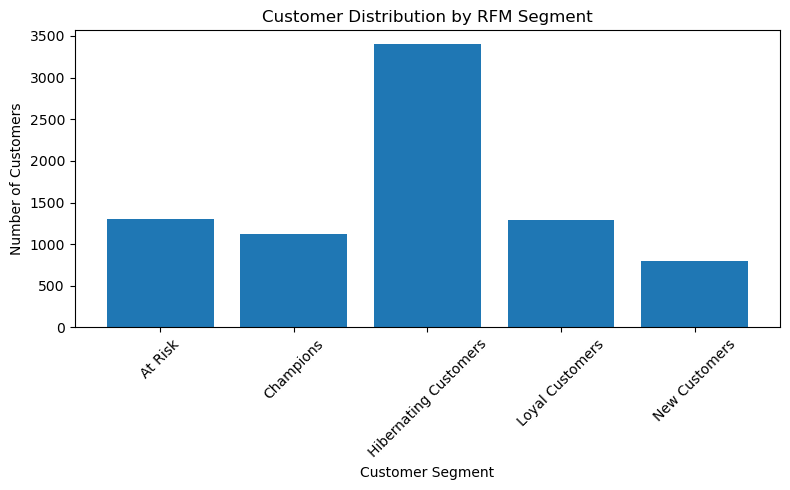

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis['Segment'],
    segment_analysis['Customer_Count']
)

plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

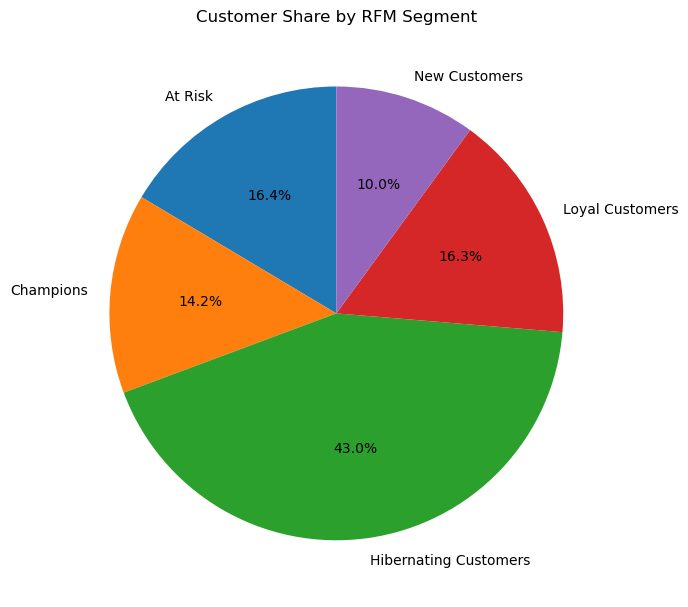

In [60]:
plt.figure(figsize=(7, 7))

plt.pie(
    segment_analysis['Customer_Percentage'],
    labels=segment_analysis['Segment'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Share by RFM Segment')
plt.tight_layout()
plt.show()

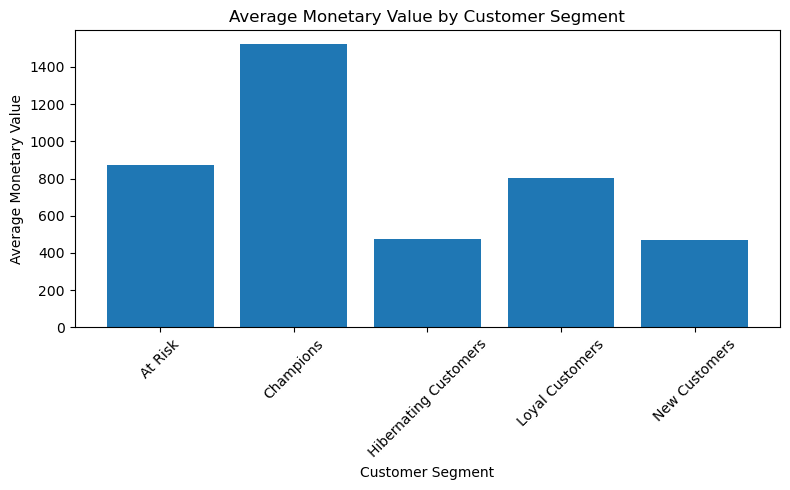

In [61]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis['Segment'],
    segment_analysis['Avg_Monetary']
)

plt.title('Average Monetary Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Monetary Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

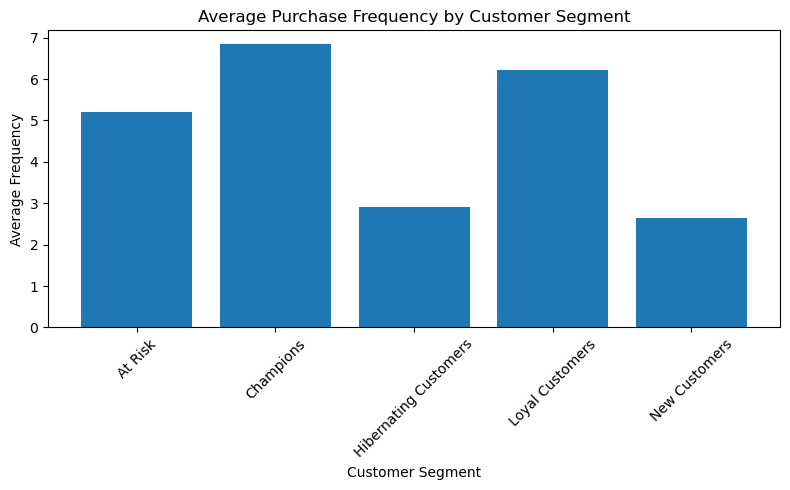

In [62]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis['Segment'],
    segment_analysis['Avg_Frequency']
)

plt.title('Average Purchase Frequency by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

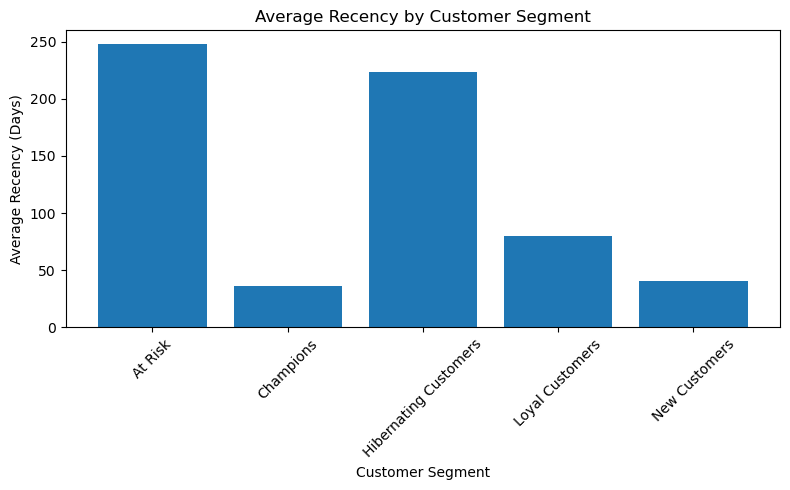

In [63]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis['Segment'],
    segment_analysis['Avg_Recency']
)

plt.title('Average Recency by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Recency (Days)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

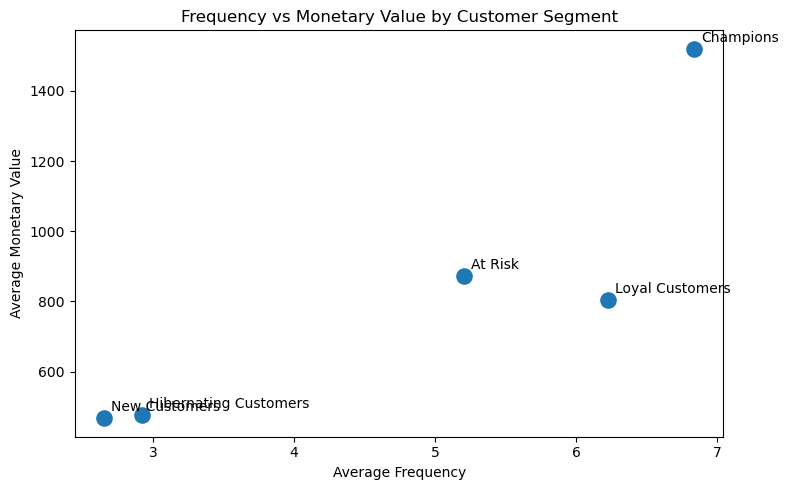

In [64]:
plt.figure(figsize=(8, 5))

plt.scatter(
    segment_analysis['Avg_Frequency'],
    segment_analysis['Avg_Monetary'],
    s=120
)

for i, row in segment_analysis.iterrows():
    plt.annotate(
        row['Segment'],
        (row['Avg_Frequency'], row['Avg_Monetary']),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('Frequency vs Monetary Value by Customer Segment')
plt.xlabel('Average Frequency')
plt.ylabel('Average Monetary Value')
plt.tight_layout()
plt.show()

In [65]:
segment_revenue = rfm.groupby('Segment').agg(
    Total_Monetary=('Monetary', 'sum'),
    Customer_Count=('customer_id', 'count')
).reset_index()

segment_revenue['Revenue_Percentage'] = (
    segment_revenue['Total_Monetary'] /
    segment_revenue['Total_Monetary'].sum()
) * 100

segment_revenue


,Segment,Total_Monetary,Customer_Count,Revenue_Percentage
0,At Risk,1132795.93,1299,19.313544
1,Champions,1711779.23,1126,29.184888
2,Hibernating Customers,1615872.81,3398,27.549737
3,Loyal Customers,1034430.06,1287,17.636460
4,New Customers,370415.02,793,6.315371


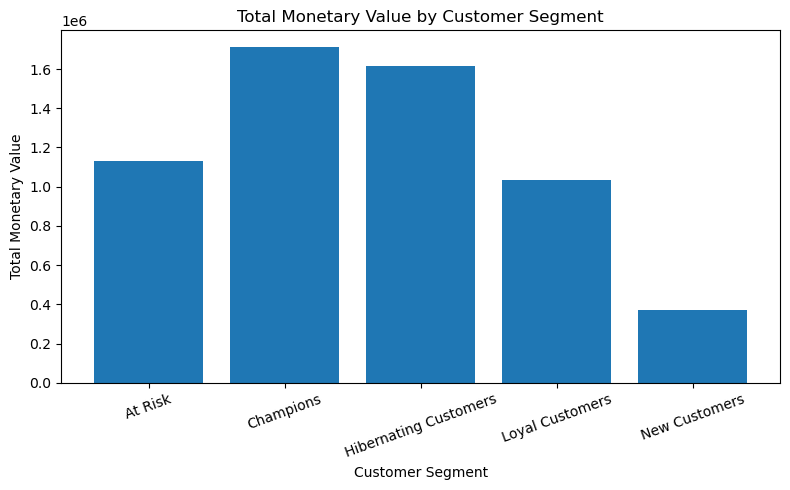

In [66]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_revenue['Segment'],
    segment_revenue['Total_Monetary']
)

plt.title('Total Monetary Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Monetary Value')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [67]:
final_summary = rfm.groupby('Segment').agg(
    Customer_Count=('customer_id', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Monetary=('Monetary', 'sum')
).reset_index()

final_summary['Customer_Percentage'] = (
    final_summary['Customer_Count'] /
    final_summary['Customer_Count'].sum()
) * 100

final_summary

,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Customer_Percentage
0,At Risk,1299,247.399538,5.207082,872.052294,1132795.93,16.436796
1,Champions,1126,35.893428,6.835702,1520.230222,1711779.23,14.247754
2,Hibernating Customers,3398,223.587110,2.921130,475.536436,1615872.81,42.996331
3,Loyal Customers,1287,80.002331,6.222999,803.752960,1034430.06,16.284955
4,New Customers,793,40.534678,2.653216,467.105952,370415.02,10.034164


In [68]:
rfm.to_csv("RFM_Customer_Segmentation.csv", index=False)

The RFM analysis helped identify different customer behavior patterns based on recency, purchase frequency and monetary value. The segmentation can be used to understand customer engagement and support targeted marketing strategies for different customer groups.